# Food Waste Analytics Pipeline — Exploratory Analysis

**Dataset:** Global Food Wastage Dataset (2018–2024) — Kaggle, Atharva Soundankar
**Author:** Pietro Masiero

This notebook translates the SQL analysis in [`sql/02_analysis.sql`](../sql/02_analysis.sql)
into Python (pandas + matplotlib/seaborn), reproducing each query as a
visualization. It demonstrates the same analytical logic applied
professionally to the Waste Watch Brazil program at Sodexo, using public data.

**Sections:**
1. Top 20 countries by total waste
2. Waste per capita ranking
3. Global trend over time
4. Waste by food category
5. Year-over-year change by country
6. Brazil deep dive
7. Economic impact analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/global_food_wastage_dataset.csv")
df.head()


,Country,Year,Food Category,Total Waste (Tons),Economic Loss (Million $),Avg Waste per Capita (Kg),Population (Million),Household Waste (%)
0,Australia,2019,Fruits & Vegetables,19268.63,18686.68,72.69,87.59,53.64
1,Indonesia,2019,Prepared Food,3916.97,4394.48,192.52,1153.99,30.61
2,Germany,2022,Dairy Products,9700.16,8909.16,166.94,1006.11,48.08
3,France,2023,Fruits & Vegetables,46299.69,40551.22,120.19,953.05,31.91
4,France,2023,Beverages,33096.57,36980.82,104.74,1105.47,36.06


In [2]:
df.info()
print(f"\nYears covered: {df['Year'].min()}–{df['Year'].max()}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Food categories: {df['Food Category'].nunique()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    5000 non-null   object 
 1   Year                       5000 non-null   int64  
 2   Food Category              5000 non-null   object 
 3   Total Waste (Tons)         5000 non-null   float64
 4   Economic Loss (Million $)  5000 non-null   float64
 5   Avg Waste per Capita (Kg)  5000 non-null   float64
 6   Population (Million)       5000 non-null   float64
 7   Household Waste (%)        5000 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 312.6+ KB

Years covered: 2018–2024
Countries: 20
Food categories: 8


## 1. Top 20 countries by total waste (latest year)

Equivalent to `sql/02_analysis.sql` — Query 1.


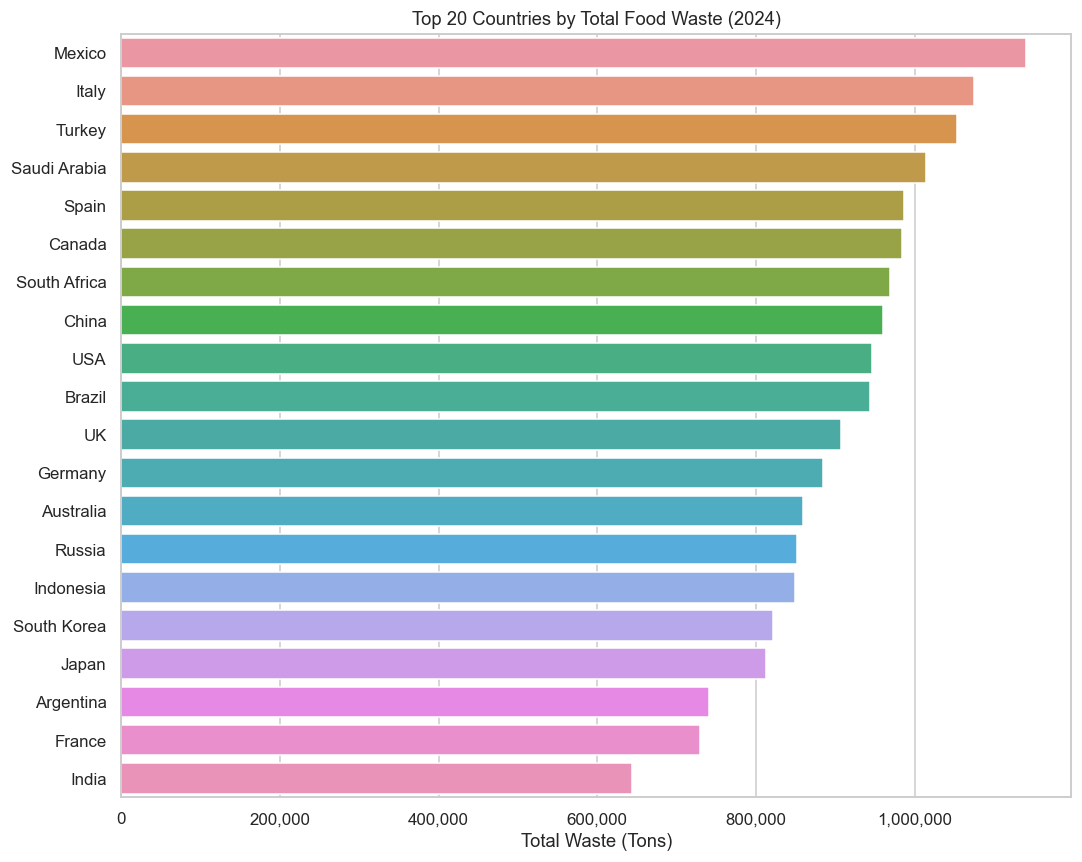

,Country,total_waste_tons,total_economic_loss
11,Mexico,1140293.74,1151823.94
9,Italy,1074171.67,1042279.74
17,Turkey,1052913.58,1037173.76
13,Saudi Arabia,1014545.85,1031343.42
16,Spain,985878.46,1012660.01
3,Canada,984274.59,970458.37
14,South Africa,968937.93,979782.50
4,China,960186.97,977076.85
19,USA,945506.12,943432.91
2,Brazil,944002.75,928154.11


In [3]:
latest_year = df["Year"].max()

top20_waste = (
    df[df["Year"] == latest_year]
    .groupby("Country", as_index=False)
    .agg(total_waste_tons=("Total Waste (Tons)", "sum"),
         total_economic_loss=("Economic Loss (Million $)", "sum"))
    .sort_values("total_waste_tons", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top20_waste, y="Country", x="total_waste_tons", ax=ax)
ax.set_title(f"Top 20 Countries by Total Food Waste ({latest_year})")
ax.set_xlabel("Total Waste (Tons)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

top20_waste


## 2. Waste per capita ranking (latest year)

Equivalent to Query 2.


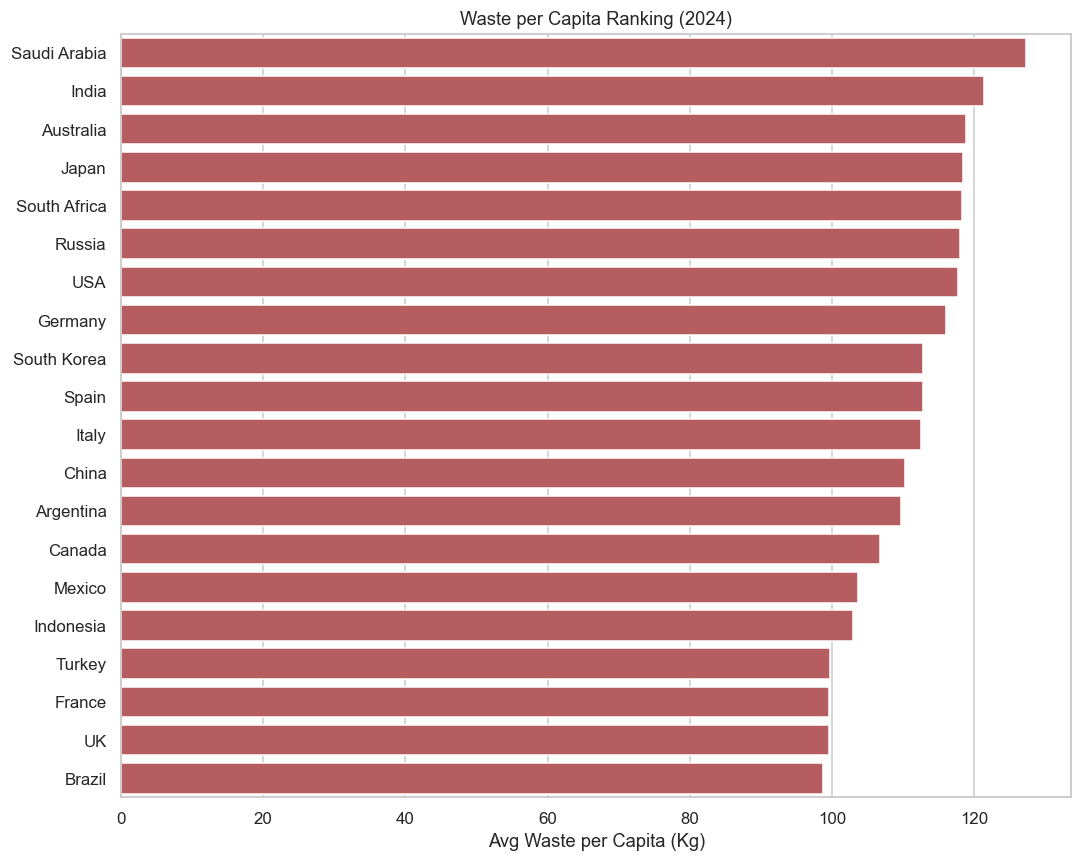

,Country,avg_waste_per_capita_kg,avg_household_waste_pct
13,Saudi Arabia,127.27,50.31
7,India,121.37,51.81
1,Australia,118.82,43.52
10,Japan,118.34,49.98
14,South Africa,118.20,48.70
12,Russia,118.01,51.00
19,USA,117.71,51.04
6,Germany,115.96,50.13
15,South Korea,112.70,49.04
16,Spain,112.70,49.16


In [5]:
per_capita = (
    df[df["Year"] == latest_year]
    .groupby("Country", as_index=False)
    .agg(avg_waste_per_capita_kg=("Avg Waste per Capita (Kg)", "mean"),
         avg_household_waste_pct=("Household Waste (%)", "mean"))
    .sort_values("avg_waste_per_capita_kg", ascending=False)
    .head(20)
)
per_capita = per_capita.round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=per_capita, y="Country", x="avg_waste_per_capita_kg",
            color="#c44e52", ax=ax)
ax.set_title(f"Waste per Capita Ranking ({latest_year})")
ax.set_xlabel("Avg Waste per Capita (Kg)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

per_capita


## 3. Global trend over time (2018–2024)

Equivalent to Query 3.


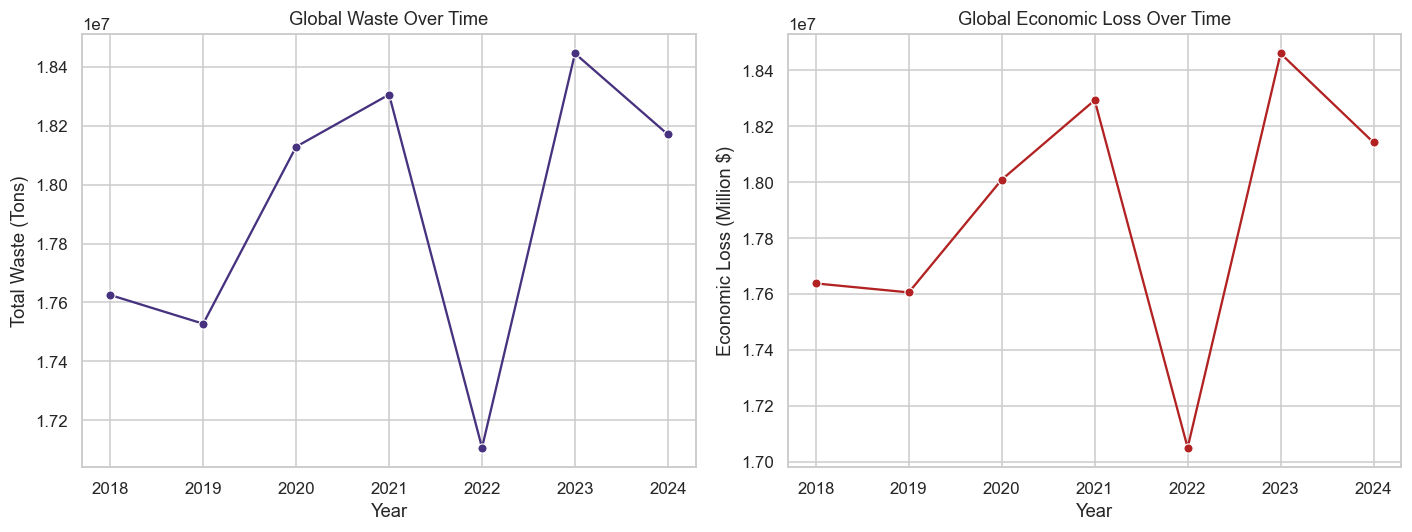

,Year,global_waste_tons,global_economic_loss,countries_reporting,avg_waste_per_capita_kg
0,2018,17625290.55,17637992.97,20,108.93
1,2019,17527936.61,17605874.24,20,107.82
2,2020,18128400.36,18008964.34,20,110.85
3,2021,18305242.89,18292911.12,20,107.36
4,2022,17107497.90,17050887.37,20,110.39
5,2023,18444672.83,18459985.67,20,109.68
6,2024,18169859.22,18141903.64,20,111.21


In [6]:
trend = (
    df.groupby("Year", as_index=False)
    .agg(global_waste_tons=("Total Waste (Tons)", "sum"),
         global_economic_loss=("Economic Loss (Million $)", "sum"),
         countries_reporting=("Country", "nunique"),
         avg_waste_per_capita_kg=("Avg Waste per Capita (Kg)", "mean"))
    .sort_values("Year")
)
trend["avg_waste_per_capita_kg"] = trend["avg_waste_per_capita_kg"].round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=trend, x="Year", y="global_waste_tons", marker="o", ax=axes[0])
axes[0].set_title("Global Waste Over Time")
axes[0].set_ylabel("Total Waste (Tons)")

sns.lineplot(data=trend, x="Year", y="global_economic_loss", marker="o",
             color="firebrick", ax=axes[1])
axes[1].set_title("Global Economic Loss Over Time")
axes[1].set_ylabel("Economic Loss (Million $)")

plt.tight_layout()
plt.show()

trend


## 4. Waste by food category (all years)

Equivalent to Query 4.


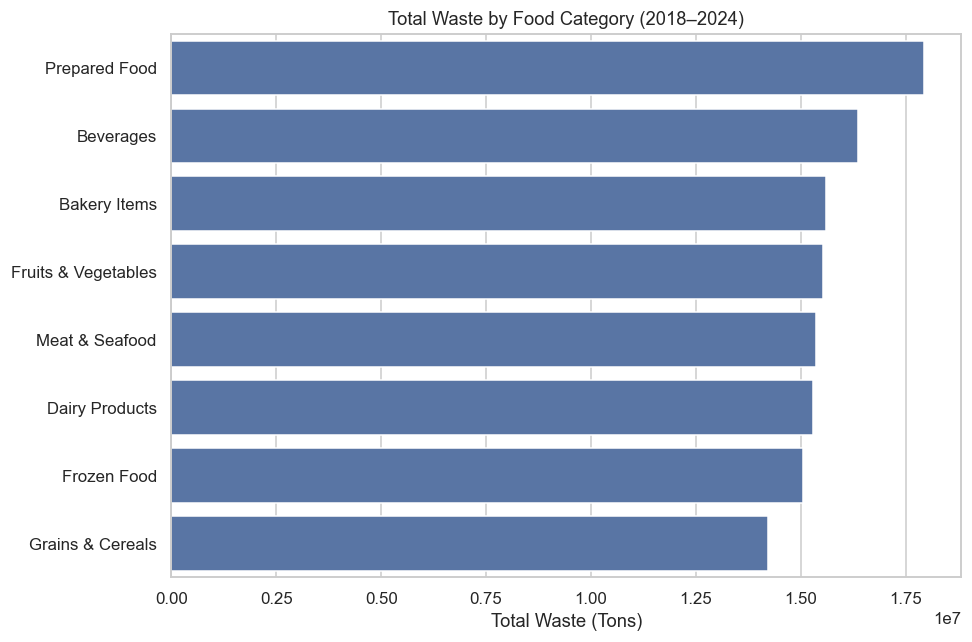

,Food Category,total_waste_tons,total_economic_loss,avg_waste_per_capita_kg,pct_of_total_waste
7,Prepared Food,17929317.92,17878643.94,108.16,14.31
1,Beverages,16354455.29,16331179.83,110.11,13.05
0,Bakery Items,15587955.51,15536973.93,110.72,12.44
4,Fruits & Vegetables,15522081.20,15622033.18,109.22,12.39
6,Meat & Seafood,15371347.52,15352228.39,109.11,12.27
2,Dairy Products,15292167.33,15223458.70,111.35,12.20
3,Frozen Food,15045115.02,15180582.95,109.69,12.01
5,Grains & Cereals,14206460.57,14073418.43,107.39,11.34


In [9]:
by_category = (
    df.groupby("Food Category", as_index=False)
    .agg(total_waste_tons=("Total Waste (Tons)", "sum"),
         total_economic_loss=("Economic Loss (Million $)", "sum"),
         avg_waste_per_capita_kg=("Avg Waste per Capita (Kg)", "mean"))
    .sort_values("total_waste_tons", ascending=False)
)
by_category["pct_of_total_waste"] = (
    by_category["total_waste_tons"] / by_category["total_waste_tons"].sum() * 100
).round(2)
by_category["avg_waste_per_capita_kg"] = by_category["avg_waste_per_capita_kg"].round(2)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=by_category, y="Food Category", x="total_waste_tons",
            color="#4c72b0", ax=ax)
ax.set_title("Total Waste by Food Category (2018–2024)")
ax.set_xlabel("Total Waste (Tons)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

by_category


## 5. Year-over-year change by country

Equivalent to Query 5 (`LAG` window function → pandas `.shift()`).


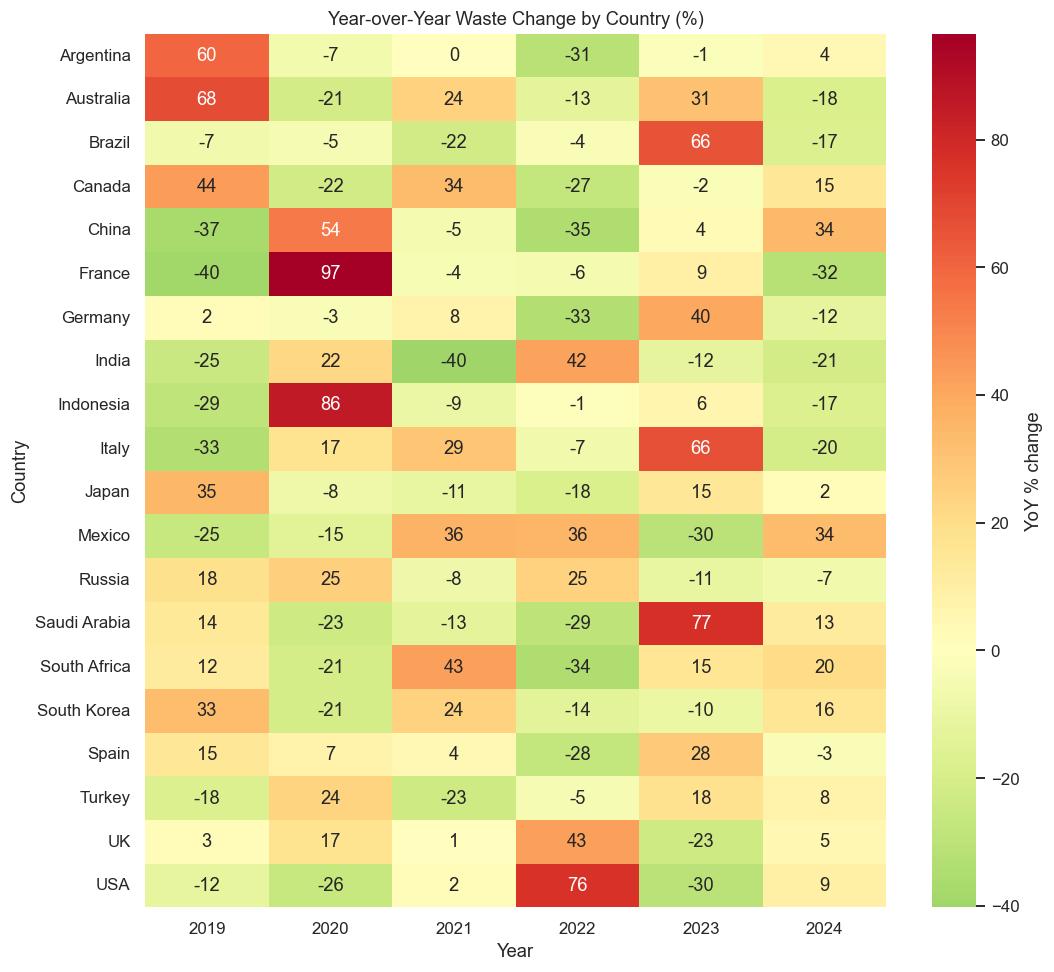

,Country,Year,total_waste_tons,prev_year_waste,pct_change_yoy
1,Argentina,2019,1118055.87,698608.25,60.04
2,Argentina,2020,1044925.92,1118055.87,-6.54
3,Argentina,2021,1049654.59,1044925.92,0.45
4,Argentina,2022,720036.35,1049654.59,-31.40
5,Argentina,2023,710130.01,720036.35,-1.38
6,Argentina,2024,740956.53,710130.01,4.34
8,Australia,2019,945352.13,562232.79,68.14
9,Australia,2020,746164.71,945352.13,-21.07
10,Australia,2021,924980.38,746164.71,23.96
11,Australia,2022,800291.66,924980.38,-13.48


In [10]:
yearly_by_country = (
    df.groupby(["Country", "Year"], as_index=False)
    .agg(total_waste_tons=("Total Waste (Tons)", "sum"))
    .sort_values(["Country", "Year"])
)

yearly_by_country["prev_year_waste"] = (
    yearly_by_country.groupby("Country")["total_waste_tons"].shift(1)
)
yearly_by_country["pct_change_yoy"] = (
    (yearly_by_country["total_waste_tons"] - yearly_by_country["prev_year_waste"])
    / yearly_by_country["prev_year_waste"] * 100
).round(2)

yoy = yearly_by_country.dropna(subset=["pct_change_yoy"])

# Heatmap: countries x years, YoY % change
pivot = yoy.pivot(index="Country", columns="Year", values="pct_change_yoy")

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot, cmap="RdYlGn_r", center=0, annot=True, fmt=".0f",
            cbar_kws={"label": "YoY % change"}, ax=ax)
ax.set_title("Year-over-Year Waste Change by Country (%)")
plt.tight_layout()
plt.show()

yoy.sort_values(["Country", "Year"]).head(20)


## 6. Brazil deep dive

Equivalent to Query 6.


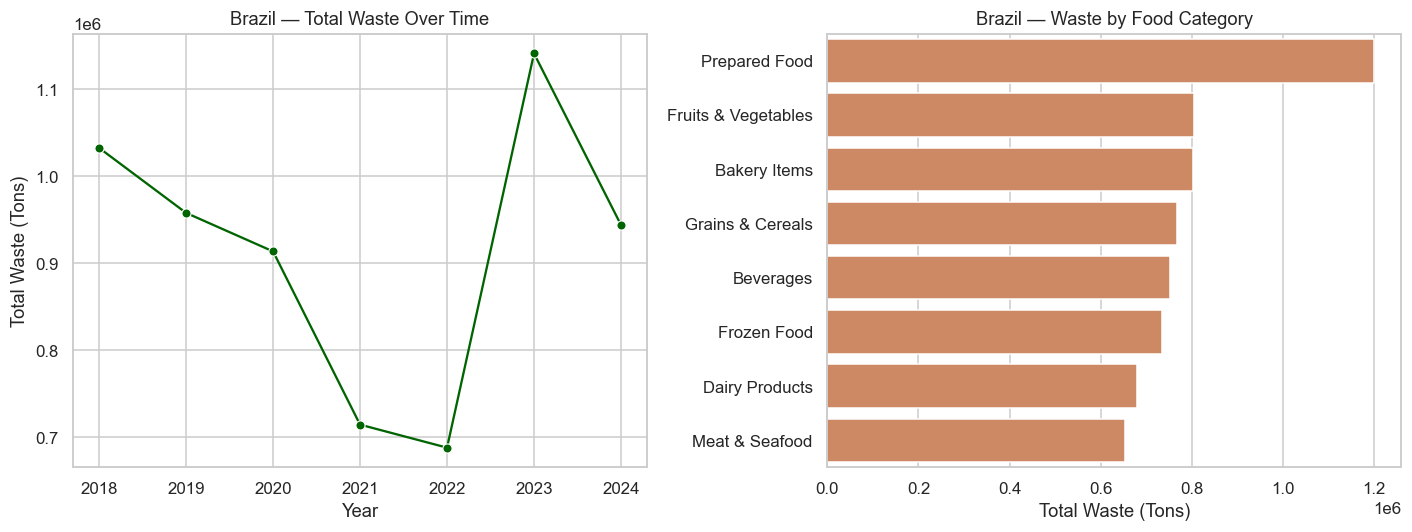

,Year,Food Category,Total Waste (Tons),Economic Loss (Million $),Avg Waste per Capita (Kg),Household Waste (%)
2473,2024,Prepared Food,8845.75,8869.07,130.81,35.45
810,2024,Bakery Items,49284.51,52917.99,116.39,40.09
955,2024,Bakery Items,3712.67,3865.38,29.77,61.34
964,2024,Frozen Food,29138.47,29241.06,119.04,45.59
980,2024,Grains & Cereals,46528.85,37983.77,95.75,44.13
996,2024,Grains & Cereals,4554.03,4992.48,27.30,45.99
1079,2024,Grains & Cereals,27207.95,27249.53,151.93,43.24
1122,2024,Prepared Food,29820.20,30839.88,93.78,59.04
3894,2024,Bakery Items,10227.92,9614.77,52.35,61.37
3819,2024,Prepared Food,48171.35,54688.41,62.15,35.65


In [11]:
brazil = (
    df[df["Country"] == "Brazil"]
    .sort_values(["Year"], ascending=False)
    [["Year", "Food Category", "Total Waste (Tons)", "Economic Loss (Million $)",
      "Avg Waste per Capita (Kg)", "Household Waste (%)"]]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

brazil_by_year = brazil.groupby("Year", as_index=False)["Total Waste (Tons)"].sum()
sns.lineplot(data=brazil_by_year, x="Year", y="Total Waste (Tons)",
             marker="o", ax=axes[0], color="darkgreen")
axes[0].set_title("Brazil — Total Waste Over Time")

brazil_by_cat = (
    brazil.groupby("Food Category", as_index=False)["Total Waste (Tons)"]
    .sum().sort_values("Total Waste (Tons)", ascending=False)
)
sns.barplot(data=brazil_by_cat, y="Food Category", x="Total Waste (Tons)",
            color="#dd8452", ax=axes[1])
axes[1].set_title("Brazil — Waste by Food Category")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

brazil.head(20)


## 7. Economic impact analysis

Equivalent to Query 7.


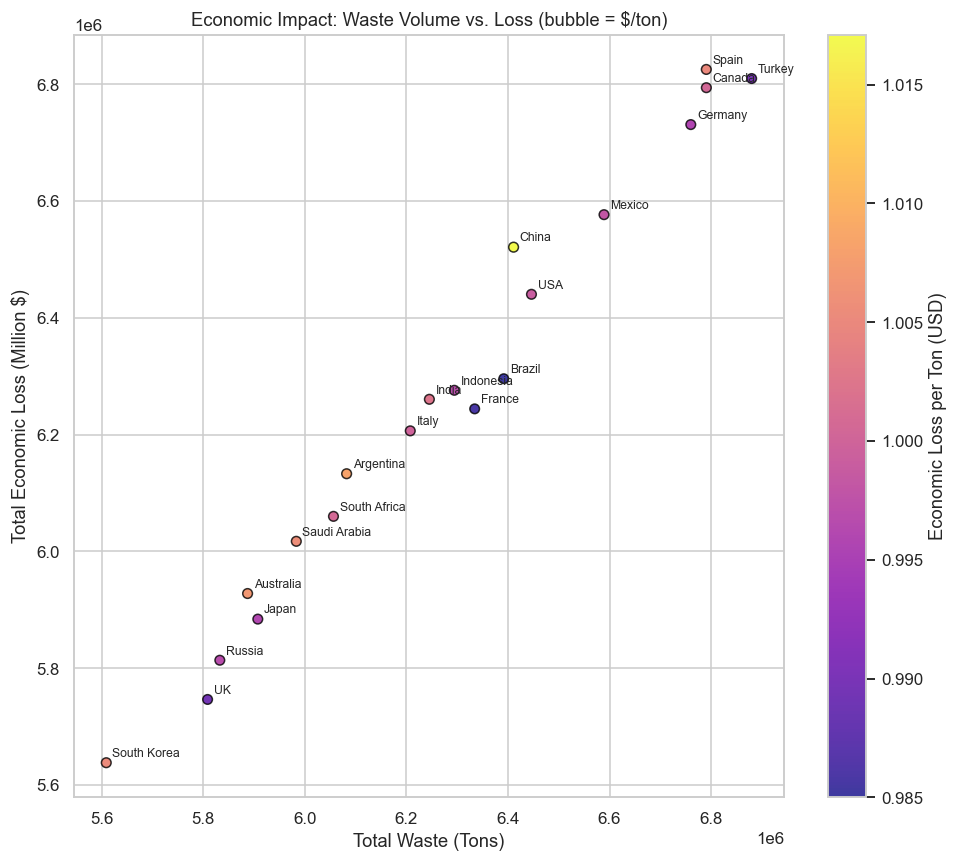

,Country,total_waste_tons,total_economic_loss,economic_loss_per_ton_usd
16,Spain,6790574.25,6825152.37,1.0051
17,Turkey,6879885.81,6809560.62,0.9898
3,Canada,6790678.49,6793901.16,1.0005
6,Germany,6760053.01,6730719.94,0.9957
11,Mexico,6589169.52,6576477.28,0.9981
4,China,6411096.18,6520823.56,1.0171
19,USA,6446334.63,6440123.44,0.9990
2,Brazil,6391752.50,6295592.19,0.9850
8,Indonesia,6294447.74,6275755.68,0.9970
7,India,6245313.77,6260349.14,1.0024


In [12]:
econ = (
    df.groupby("Country", as_index=False)
    .agg(total_waste_tons=("Total Waste (Tons)", "sum"),
         total_economic_loss=("Economic Loss (Million $)", "sum"))
    .sort_values("total_economic_loss", ascending=False)
)
econ["economic_loss_per_ton_usd"] = (
    econ["total_economic_loss"] / econ["total_waste_tons"]
).round(4)
top20_econ = econ.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    top20_econ["total_waste_tons"],
    top20_econ["total_economic_loss"],
    s=top20_econ["economic_loss_per_ton_usd"] * 40,
    c=top20_econ["economic_loss_per_ton_usd"],
    cmap="plasma", alpha=0.8, edgecolors="black"
)
for _, row in top20_econ.iterrows():
    ax.annotate(row["Country"], (row["total_waste_tons"], row["total_economic_loss"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Total Waste (Tons)")
ax.set_ylabel("Total Economic Loss (Million $)")
ax.set_title("Economic Impact: Waste Volume vs. Loss (bubble = $/ton)")
plt.colorbar(scatter, label="Economic Loss per Ton (USD)")
plt.tight_layout()
plt.show()

top20_econ


## Key takeaways

- Fill in with your own narrative once you review the outputs above — e.g. which countries/categories drive the most waste, how Brazil compares globally, and which markets show the steepest YoY increases.
- This mirrors the same KPI logic (compliance, per-capita, reduction vs. baseline) used in the Waste Watch Brazil program, applied here to public data for portfolio purposes.

**Related work:**
- SQL queries: [`sql/02_analysis.sql`](../sql/02_analysis.sql)
- dbt project (staging → marts, tested and documented): [`dbt_project/`](../dbt_project/)

**Possible next steps:**
- [ ] Load dbt models into a cloud warehouse (BigQuery/Snowflake) instead of local DuckDB
- [ ] Optional: rebuild visuals in Plotly/Streamlit for an interactive app